# Post 06: When Is a Trajectory Long Enough to Trust?

This notebook is the presentation layer for the sixth tutorial. The reusable trajectory-length diagnostics and figure logic live in `src/kups_md_tutorials/`.

The goal is to distinguish raw frame count from effective sample count, uncertainty, and replica agreement.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.figures import generate_post06_figures
from kups_md_tutorials.trajectory_length import load_trajectory_length_summary

## Configuration

The smoke and full profiles use a controlled correlated observable with a known equilibrium mean. This makes it possible to test warmup removal, autocorrelation, effective sample size, block uncertainty, and independent replica agreement directly.

In [3]:
for profile in ["smoke", "full"]:
    print(f"--- {profile} ---")
    print(json.dumps(json.loads(Path(f"configs/post-06/{profile}.json").read_text()), indent=2))

--- smoke ---
{
  "post": "06",
  "profile": "smoke",
  "title": "When Is a Trajectory Long Enough to Trust?",
  "trajectory_length_experiment": {
    "true_mean": 0.5,
    "stationary_variance": 1.0,
    "correlation_time": 30.0,
    "equilibration_time": 120.0,
    "initial_bias": 2.5,
    "time_step": 1.0,
    "max_steps": 2500,
    "warmup_steps": 250,
    "sample_every": 2,
    "replica_count": 4,
    "seed": 2026071406,
    "checkpoints": [
      500,
      1000,
      2500
    ]
  }
}
--- full ---
{
  "post": "06",
  "profile": "full",
  "title": "When Is a Trajectory Long Enough to Trust?",
  "trajectory_length_experiment": {
    "true_mean": 0.5,
    "stationary_variance": 1.0,
    "correlation_time": 30.0,
    "equilibration_time": 120.0,
    "initial_bias": 2.5,
    "time_step": 1.0,
    "max_steps": 24000,
    "warmup_steps": 1000,
    "sample_every": 4,
    "replica_count": 6,
    "seed": 2026071406,
    "checkpoints": [
      2000,
      6000,
      12000,
      24000
   

## Committed Results

The summary reports naive standard error, autocorrelation-aware standard error, block standard error, replica standard error, and the conservative uncertainty used for review.

In [4]:
summary = load_trajectory_length_summary(Path("results/post-06/full/trajectory_length_summary.json"))
for checkpoint in summary.checkpoints:
    print(
        checkpoint.checkpoint_steps,
        "mean=", round(checkpoint.mean_estimate, 4),
        "ESS=", round(checkpoint.effective_samples, 1),
        "naive SE=", round(checkpoint.naive_standard_error, 4),
        "conservative SE=", round(checkpoint.conservative_standard_error, 4),
        "95% half-width=", round(checkpoint.conservative_ci95_half_width, 4),
    )

2000 mean= 0.4094 ESS= 148.9 naive SE= 0.0271 conservative SE= 0.1617 95% half-width= 0.317
6000 mean= 0.5108 ESS= 580.7 naive SE= 0.0112 conservative SE= 0.0571 95% half-width= 0.112
12000 mean= 0.4901 ESS= 996.8 naive SE= 0.0077 conservative SE= 0.0422 95% half-width= 0.0827
24000 mean= 0.4936 ESS= 2295.6 naive SE= 0.0054 conservative SE= 0.0208 95% half-width= 0.0408


## Figure

The full-profile figure is regenerated from committed compact outputs.

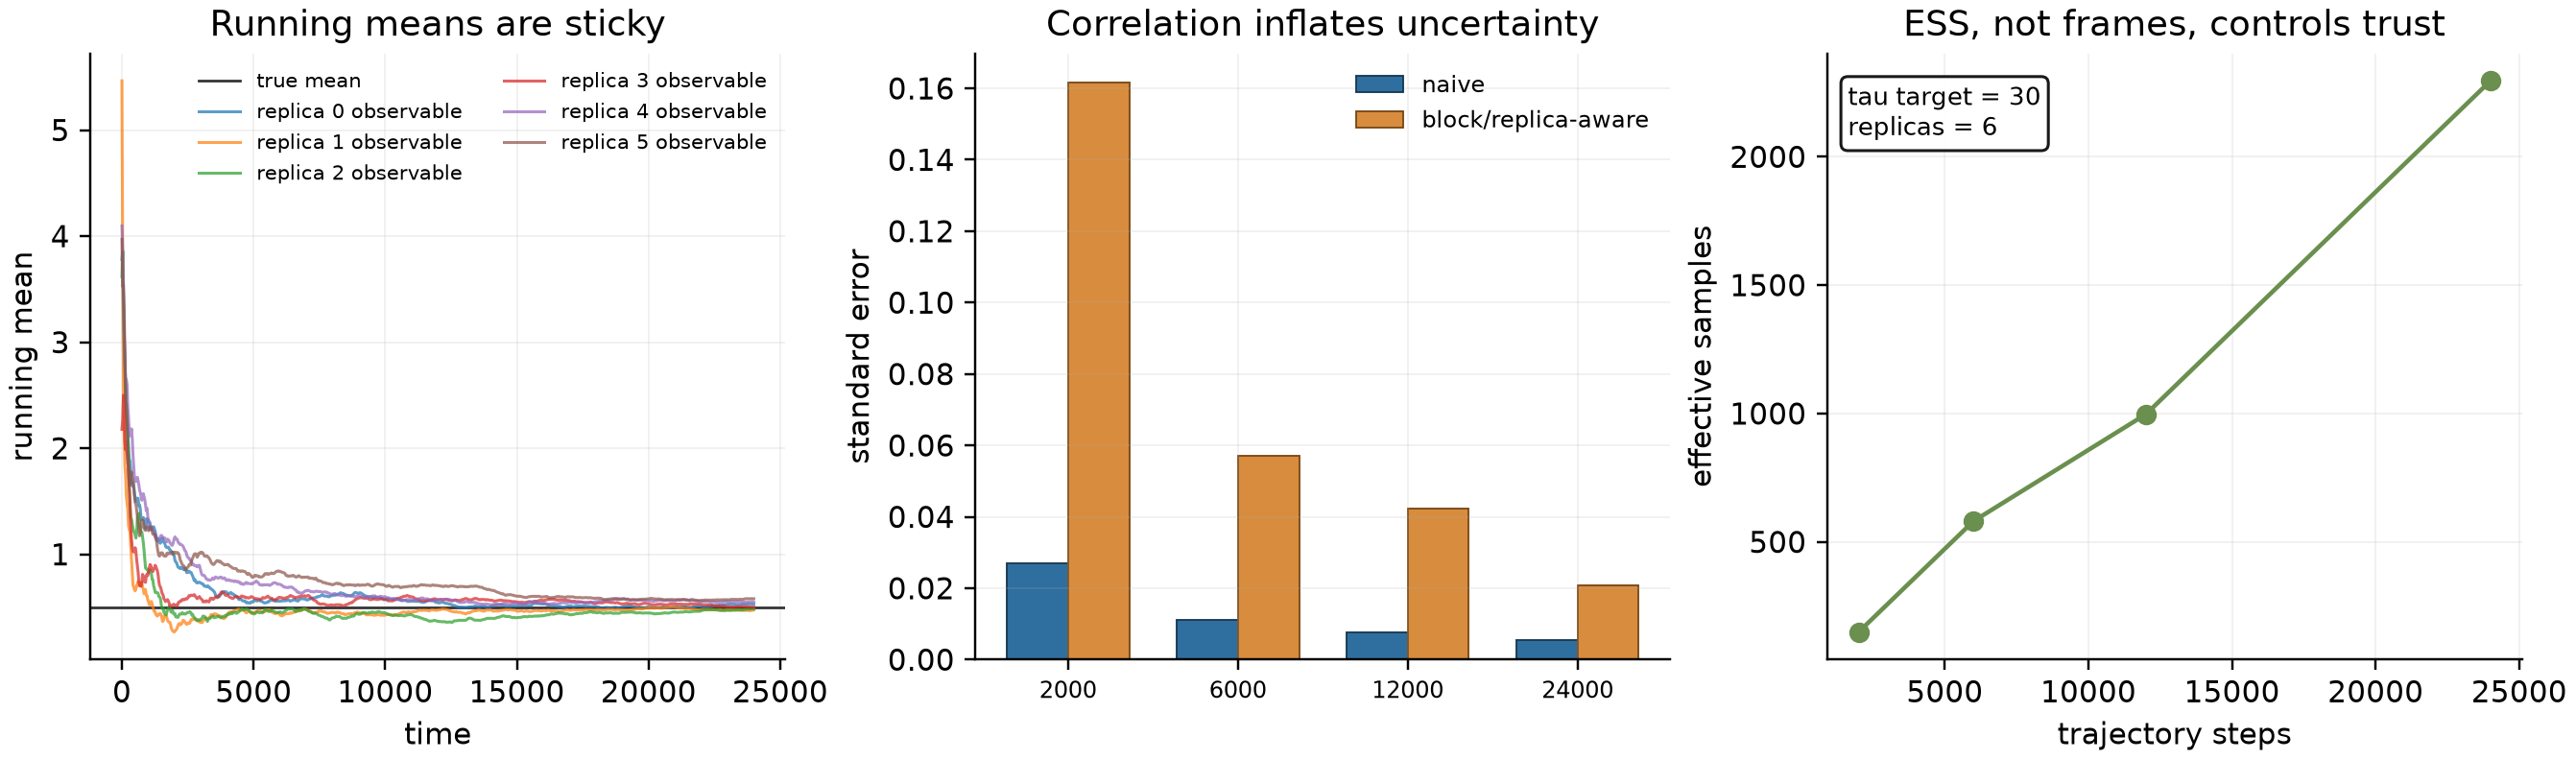

In [5]:
generate_post06_figures(
    result_dir=Path("results/post-06/full"),
    figure_dir=Path("figures/post-06"),
    snapshot_dir=Path("snapshots/post-06"),
    name="trajectory_length_diagnostics_full",
)
display(Image(filename="figures/post-06/trajectory_length_diagnostics_full.png"))